#  Statistics with Python: Culminating Activity  <hr style="border:2.5px solid #126782"></hr>

<b> Daniel Udasco </b>
<br> 3rd Year Comp Eng Tech Student

# Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (shapiro, ttest_1samp, ttest_ind, ttest_rel)
from statsmodels.stats.power import TTestPower

# Import "student_data.csv" Dataset

In [11]:
df = pd.read_csv("unprocessed/student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,1st_semester,2nd_semester,3rd_semester
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Dataset Information

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        395 non-null    object
 1   sex           395 non-null    object
 2   age           395 non-null    int64 
 3   address       395 non-null    object
 4   famsize       395 non-null    object
 5   Pstatus       395 non-null    object
 6   Medu          395 non-null    int64 
 7   Fedu          395 non-null    int64 
 8   Mjob          395 non-null    object
 9   Fjob          395 non-null    object
 10  reason        395 non-null    object
 11  guardian      395 non-null    object
 12  traveltime    395 non-null    int64 
 13  studytime     395 non-null    int64 
 14  failures      395 non-null    int64 
 15  schoolsup     395 non-null    object
 16  famsup        395 non-null    object
 17  paid          395 non-null    object
 18  activities    395 non-null    object
 19  nursery 

In [13]:
df.shape

(395, 33)

# Descriptive Statistics

In [14]:
df[['1st_semester','2nd_semester','3rd_semester']].describe()

,1st_semester,2nd_semester,3rd_semester
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


# Boxplot for Outlier Detection

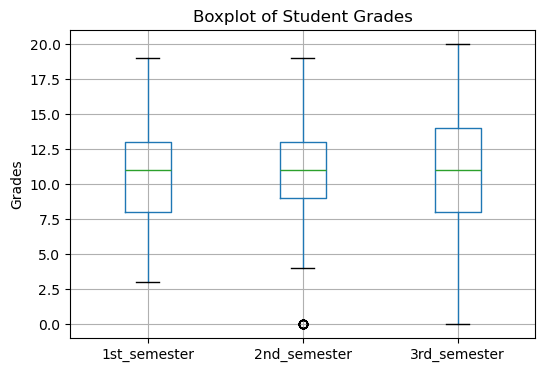

In [15]:
plt.figure(figsize=(6,4))

df[['1st_semester','2nd_semester','3rd_semester']].boxplot()

plt.title("Boxplot of Student Grades")
plt.ylabel("Grades")
plt.show()

# Shapiro-Wilk Normality Test

In [16]:
stat, p = shapiro(df['1st_semester'])

print("Shapiro Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Data is normally distributed")
else:
    print("Data is not normally distributed")

Shapiro Statistic: 0.9749134463536325
p-value: 2.4541585453327336e-06
Data is not normally distributed


# One-Sample T-Test

In [17]:
t_stat, p_value = ttest_1samp(df['3rd_semester'], 10)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

T-statistic: 1.8011216618076253
p-value: 0.07244819813279511
Fail to reject the null hypothesis


# Cohen’s d (Effect Size)

In [18]:
sample_mean = df['3rd_semester'].mean()
pop_mean = 10
sample_std = df['3rd_semester'].std()

d = abs((sample_mean - pop_mean) / sample_std)

print("Cohen's d:", d)

Cohen's d: 0.09062426590721676


# Power Analysis

In [19]:
# Power Analysis

power = TTestPower().power(
    effect_size=d,
    nobs=df['3rd_semester'].count(),
    alpha=0.05,
    alternative='two-sided'
)

print("Statistical Power:", power*100, "%")

Statistical Power: 43.52536101495851 %


# F-Test

In [20]:
var_1st_semester = np.var(df['1st_semester'], ddof=1)
var_2nd_semester = np.var(df['2nd_semester'], ddof=1)

F = var_1st_semester / var_2nd_semester

print("Variance of 1st_semester:", var_1st_semester)
print("Variance of 2nd_semester:", var_2nd_semester)
print("F-statistic:", F)

Variance of 1st_semester: 11.017053267364899
Variance of 2nd_semester: 14.148917303861756
F-statistic: 0.7786499158036596


# Independent Two-Sample T-Test

In [21]:
t_stat, p_value = ttest_ind(df['1st_semester'], df['2nd_semester'])

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

T-statistic: 0.7722987557628348
p-value: 0.4401690624225727
Fail to reject the null hypothesis


# Paired T-Test

In [22]:
t_stat, p_value = ttest_rel(df['1st_semester'], df['3rd_semester'])

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

T-statistic: 3.5517031247185855
p-value: 0.0004290673865804163
Reject the null hypothesis


# Sampling Distribution of the Mean

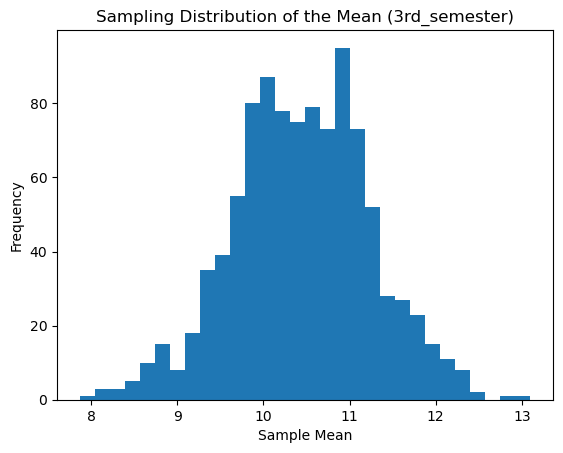

In [23]:
sample_means = []

for i in range(1000):
    sample = df['3rd_semester'].sample(30)
    sample_means.append(sample.mean())

plt.hist(sample_means, bins=30)

plt.title("Sampling Distribution of the Mean (3rd_semester)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

# Conclusion

<h5 style="color: cyan; text-indent: 50px;">
    The statistical analysis of student grades shows that the distributions of the grades are approximately normal. The t-tests were used to compare mean grades across semesters. The paired t-test indicates whether students' performance changed from the first semester to the final semester.
<h5>